In [27]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [28]:
username = "postgres"
password = quote_plus("Siri@22032004")
host = "localhost"
port = "5432"
database = "enterprise_ecommerce"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

In [ ]:
customers = pd.read_sql(
    "SELECT * FROM customers",
    engine
)
customers.head()

,customer_id,first_name,last_name,gender,age,city,state,country,join_date
0,1,Vrishti,Sibal,Male,19,Jehanabad,Tamil Nadu,India,2025-11-11
1,2,Nikita,Sarma,Female,33,Panvel,Tamil Nadu,India,2022-10-31
2,3,Girik,Chahal,Male,26,Nagpur,Kerala,India,2024-06-06
3,4,Urvashi,Lall,Male,61,Gandhinagar,Andhra Pradesh,India,2024-12-08
4,5,Nitesh,Bakshi,Male,55,Kavali,Madhya Pradesh,India,2024-05-23


In [37]:
# Load all tables from PostgreSQL into Pandas

categories = pd.read_sql(
    "SELECT * FROM categories",
    engine
)

customers = pd.read_sql(
    "SELECT * FROM customers",
    engine
)

warehouses = pd.read_sql(
    "SELECT * FROM warehouses",
    engine
)

products = pd.read_sql(
    "SELECT * FROM products",
    engine
)

inventory = pd.read_sql(
    "SELECT * FROM inventory",
    engine
)

payments = pd.read_sql(
    "SELECT * FROM payments",
    engine
)

shipping = pd.read_sql(
    "SELECT * FROM shipping",
    engine
)

orders = pd.read_sql(
    "SELECT * FROM orders",
    engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    engine
)

returns = pd.read_sql(
    "SELECT * FROM returns",
    engine
)

print("All 10 tables loaded successfully!")

All 10 tables loaded successfully!


In [ ]:
print("Categories :", len(categories))
print("Customers  :", len(customers))
print("Warehouses :", len(warehouses))
print("Products   :", len(products))
print("Inventory  :", len(inventory))
print("Payments   :", len(payments))
print("Shipping   :", len(shipping))
print("Orders     :", len(orders))
print("Order Items:", len(order_items))
print("Returns    :", len(returns))

Categories :    category_id category_name
0            1   Electronics
1            2       Fashion
2            3          Home
3            4         Books
4            5        Sports
5            6        Beauty
6            7       Grocery
7            8          Toys
8            9     Furniture
9           10        Office
Customers  : 1000
Warehouses : 5
Products   : 200
Inventory  : 1000
Payments   : 5000
Shipping   : 5000
Orders     : 5000
Order Items: 10015
Returns    : 1000


In [40]:
print("CUSTOMERS")
print(customers.shape)

print("\nPRODUCTS")
print(products.shape)

print("\nORDERS")
print(orders.shape)

print("\nORDER ITEMS")
print(order_items.shape)

print("\nINVENTORY")
print(inventory.shape)

print("\nRETURNS")
print(returns.shape)

CUSTOMERS
(1000, 9)

PRODUCTS
(200, 6)

ORDERS
(5000, 5)

ORDER ITEMS
(10015, 8)

INVENTORY
(1000, 5)

RETURNS
(1000, 5)


In [41]:
# ============================================
# DATA QUALITY CHECK
# ============================================

tables = {
    "categories": categories,
    "customers": customers,
    "warehouses": warehouses,
    "products": products,
    "inventory": inventory,
    "payments": payments,
    "shipping": shipping,
    "orders": orders,
    "order_items": order_items,
    "returns": returns
}

for table_name, df in tables.items():

    print("=" * 50)
    print(f"TABLE: {table_name}")
    print("=" * 50)

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())

    print()

TABLE: categories
Rows: 10
Columns: 2
Duplicate rows: 0
Missing values: 0

TABLE: customers
Rows: 1000
Columns: 9
Duplicate rows: 0
Missing values: 0

TABLE: warehouses
Rows: 5
Columns: 4
Duplicate rows: 0
Missing values: 0

TABLE: products
Rows: 200
Columns: 6
Duplicate rows: 0
Missing values: 0

TABLE: inventory
Rows: 1000
Columns: 5
Duplicate rows: 0
Missing values: 0

TABLE: payments
Rows: 5000
Columns: 3
Duplicate rows: 0
Missing values: 0

TABLE: shipping
Rows: 5000
Columns: 6
Duplicate rows: 0
Missing values: 0

TABLE: orders
Rows: 5000
Columns: 5
Duplicate rows: 0
Missing values: 0

TABLE: order_items
Rows: 10015
Columns: 8
Duplicate rows: 0
Missing values: 0

TABLE: returns
Rows: 1000
Columns: 5
Duplicate rows: 0
Missing values: 0



In [42]:
for table_name, df in tables.items():

    print(f"\n{table_name.upper()}")
    print(list(df.columns))


CATEGORIES
['category_id', 'category_name']

CUSTOMERS
['customer_id', 'first_name', 'last_name', 'gender', 'age', 'city', 'state', 'country', 'join_date']

WAREHOUSES
['warehouse_id', 'warehouse_name', 'city', 'state']

PRODUCTS
['product_id', 'category_id', 'product_name', 'brand', 'cost_price', 'selling_price']

INVENTORY
['inventory_id', 'warehouse_id', 'product_id', 'stock_quantity', 'reorder_level']

PAYMENTS
['payment_id', 'payment_method', 'payment_status']

SHIPPING
['shipping_id', 'warehouse_id', 'shipping_partner', 'shipping_cost', 'delivery_days', 'delivery_status']

ORDERS
['order_id', 'customer_id', 'payment_id', 'shipping_id', 'order_date']

ORDER_ITEMS
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount', 'sales', 'profit']

RETURNS
['return_id', 'order_item_id', 'return_reason', 'return_date', 'refund_amount']


In [43]:
for table_name, df in tables.items():

    print("\n" + "=" * 50)
    print(table_name.upper())
    print("=" * 50)

    print(df.dtypes)


CATEGORIES
category_id      int64
category_name      str
dtype: object

CUSTOMERS
customer_id     int64
first_name        str
last_name         str
gender            str
age             int64
city              str
state             str
country           str
join_date      object
dtype: object

WAREHOUSES
warehouse_id      int64
warehouse_name      str
city                str
state               str
dtype: object

PRODUCTS
product_id         int64
category_id        int64
product_name         str
brand                str
cost_price       float64
selling_price    float64
dtype: object

INVENTORY
inventory_id      int64
warehouse_id      int64
product_id        int64
stock_quantity    int64
reorder_level     int64
dtype: object

PAYMENTS
payment_id        int64
payment_method      str
payment_status      str
dtype: object

SHIPPING
shipping_id           int64
warehouse_id          int64
shipping_partner        str
shipping_cost       float64
delivery_days         int64
delivery_status   

In [44]:
print("ORDER ITEMS")
display(order_items.describe())

print("INVENTORY")
display(inventory.describe())

print("SHIPPING")
display(shipping.describe())

ORDER ITEMS


,order_item_id,order_id,product_id,quantity,unit_price,discount,sales,profit
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,5008.000000,2492.880479,100.628158,2.502047,3714.291011,9.959446,9260.139387,2375.358259
std,2891.225807,1436.809914,57.784263,1.126319,2015.616287,5.772110,6891.553985,2150.314084
min,1.000000,1.000000,1.000000,1.000000,198.540000,0.000000,181.440000,23.250000
25%,2504.500000,1252.000000,51.000000,1.000000,2097.220000,4.950000,3833.685000,850.725000
50%,5008.000000,2491.000000,101.000000,3.000000,3649.520000,9.960000,7292.940000,1729.230000
75%,7511.500000,3733.500000,150.000000,4.000000,5429.370000,14.965000,13564.560000,3259.720000
max,10015.000000,5000.000000,200.000000,4.000000,7914.830000,20.000000,31658.790000,11854.790000


INVENTORY


,inventory_id,warehouse_id,product_id,stock_quantity,reorder_level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,500.500000,3.000000,100.500000,255.625000,50.0
std,288.819436,1.414921,57.763194,139.198616,0.0
min,1.000000,1.000000,1.000000,20.000000,50.0
25%,250.750000,2.000000,50.750000,131.750000,50.0
50%,500.500000,3.000000,100.500000,251.500000,50.0
75%,750.250000,4.000000,150.250000,379.250000,50.0
max,1000.000000,5.000000,200.000000,500.000000,50.0


SHIPPING


,shipping_id,warehouse_id,shipping_cost,delivery_days
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,3.000600,169.283600,4.010400
std,1443.520003,1.416828,75.295021,1.994063
min,1.000000,1.000000,40.000000,1.000000
25%,1250.750000,2.000000,103.000000,2.000000
50%,2500.500000,3.000000,170.000000,4.000000
75%,3750.250000,4.000000,235.000000,6.000000
max,5000.000000,5.000000,300.000000,7.000000


In [45]:
# ============================================
# CREATE MAIN ANALYSIS DATASET
# ============================================

sales_df = (
    order_items
    .merge(
        orders,
        on="order_id",
        how="left"
    )
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
    .merge(
        categories,
        on="category_id",
        how="left"
    )
)

print("Sales dataset created successfully!")
print("Rows:", sales_df.shape[0])
print("Columns:", sales_df.shape[1])

Sales dataset created successfully!
Rows: 10015
Columns: 26


In [46]:
sales_df.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount,sales,profit,customer_id,payment_id,...,city,state,country,join_date,category_id,product_name,brand,cost_price,selling_price,category_name
0,1,1,148,2,2839.22,5.92,5672.52,2010.52,558,1,...,Bharatpur,Jharkhand,India,2024-06-27,10,Product 148,Brand 16,1831.0,2839.22,Office
1,2,1,175,1,4435.81,15.16,4420.65,871.65,558,1,...,Bharatpur,Jharkhand,India,2024-06-27,2,Product 175,Brand 12,3549.0,4435.81,Fashion
2,3,1,156,3,6188.40,19.13,18546.07,5940.07,558,1,...,Bharatpur,Jharkhand,India,2024-06-27,6,Product 156,Brand 2,4202.0,6188.40,Beauty
3,4,2,190,4,3100.22,0.23,12400.65,3724.65,185,2,...,Unnao,Odisha,India,2024-05-24,7,Product 190,Brand 13,2169.0,3100.22,Grocery
4,5,2,186,2,7914.83,18.44,15811.22,5909.22,185,2,...,Unnao,Odisha,India,2024-05-24,3,Product 186,Brand 18,4951.0,7914.83,Home


In [47]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  10015 non-null  int64  
 1   order_id       10015 non-null  int64  
 2   product_id     10015 non-null  int64  
 3   quantity       10015 non-null  int64  
 4   unit_price     10015 non-null  float64
 5   discount       10015 non-null  float64
 6   sales          10015 non-null  float64
 7   profit         10015 non-null  float64
 8   customer_id    10015 non-null  int64  
 9   payment_id     10015 non-null  int64  
 10  shipping_id    10015 non-null  int64  
 11  order_date     10015 non-null  object 
 12  first_name     10015 non-null  str    
 13  last_name      10015 non-null  str    
 14  gender         10015 non-null  str    
 15  age            10015 non-null  int64  
 16  city           10015 non-null  str    
 17  state          10015 non-null  str    
 18  country        10

In [48]:
# ============================================
# OVERALL BUSINESS KPIs
# ============================================

total_revenue = sales_df["sales"].sum()
total_profit = sales_df["profit"].sum()
total_orders = sales_df["order_id"].nunique()
total_customers = sales_df["customer_id"].nunique()
total_products = sales_df["product_id"].nunique()

average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

print(f"Total Revenue      : ₹{total_revenue:,.2f}")
print(f"Total Profit       : ₹{total_profit:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Total Products     : {total_products:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Profit Margin      : {profit_margin:.2f}%")

Total Revenue      : ₹92,740,295.96
Total Profit       : ₹23,789,212.96
Total Orders       : 5,000
Total Customers    : 993
Total Products     : 200
Average Order Value: ₹18,548.06
Profit Margin      : 25.65%


In [49]:
category_sales = (
    sales_df
    .groupby("category_name")
    .agg(
        revenue=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_sales

,revenue,profit,orders,quantity
category_name,,,,
Beauty,12093090.71,3235021.71,1006,2652
Books,11667709.30,2924504.30,1055,2899
Electronics,10787246.59,2862120.59,950,2439
Grocery,10110517.78,2123248.78,1225,3342
Home,10043232.70,3087167.70,821,2182
Furniture,8858063.68,2025690.68,852,2270
Toys,7899498.47,2567718.47,913,2504
Office,7812619.90,1733041.90,934,2516
Fashion,7081257.25,1728810.25,837,2223


In [50]:
top_products = (
    sales_df
    .groupby("product_name")
    .agg(
        revenue=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products

,revenue,profit,quantity
product_name,,,
Product 186,1052152.61,393669.61,133
Product 199,1050905.82,322655.82,150
Product 101,1004803.75,351931.75,132
Product 21,984793.48,198952.48,161
Product 126,960064.13,287004.13,146
Product 15,924878.92,228238.92,160
Product 26,911868.67,332278.67,121
Product 171,908353.55,322978.55,125
Product 3,900049.18,315751.18,117


In [51]:
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])

monthly_sales = (
    sales_df
    .groupby(
        sales_df["order_date"].dt.to_period("M")
    )
    .agg(
        revenue=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

monthly_sales

,order_date,revenue,profit,orders
0,2024-08,3405522.29,864104.29,174
1,2024-09,3606999.88,926063.88,195
2,2024-10,4202221.67,1084830.67,230
3,2024-11,3882925.01,1005890.01,211
4,2024-12,3757245.03,977186.03,197
5,2025-01,3955393.81,1053667.81,203
6,2025-02,4097093.77,1056794.77,208
7,2025-03,4307517.59,1127863.59,219
8,2025-04,4041662.76,1027629.76,214
9,2025-05,3979955.30,986004.30,217


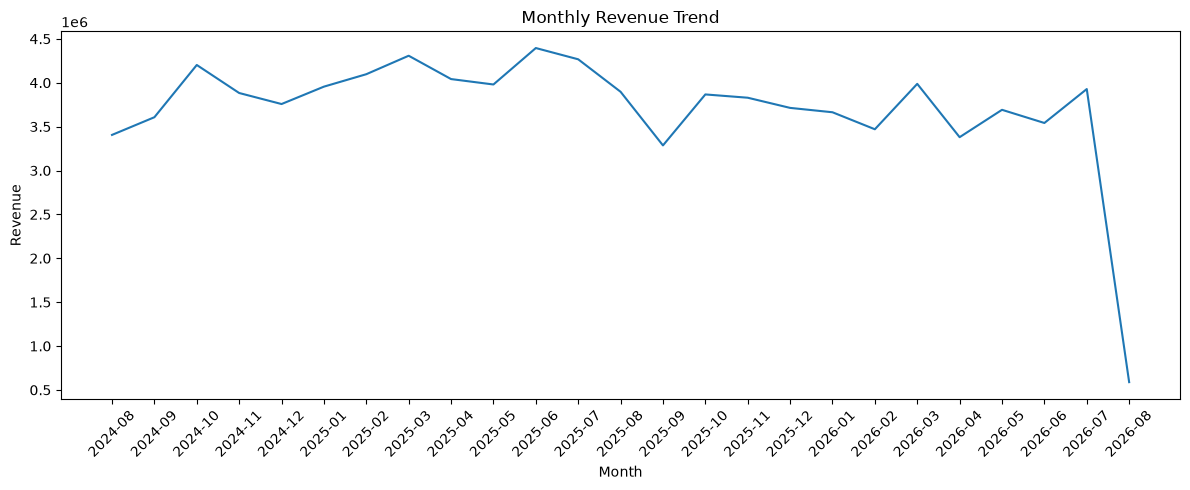

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

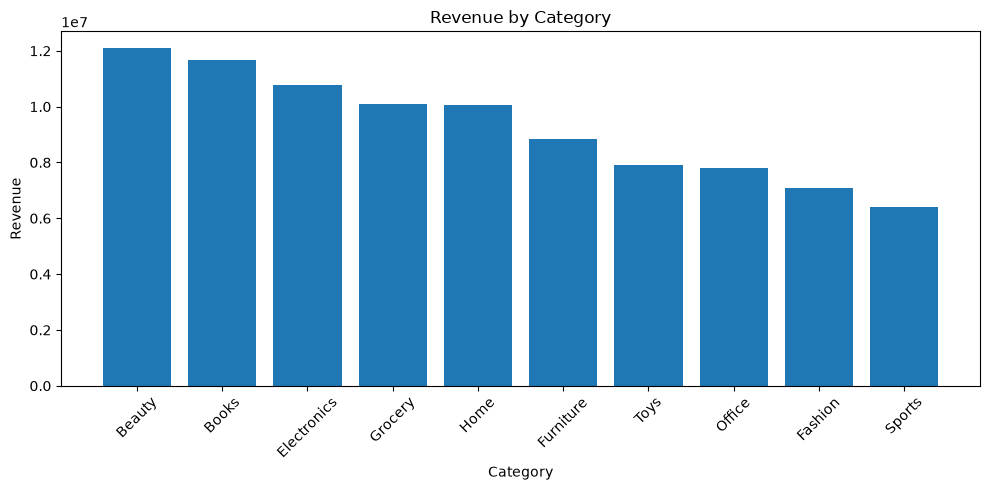

In [53]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_sales.index,
    category_sales["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

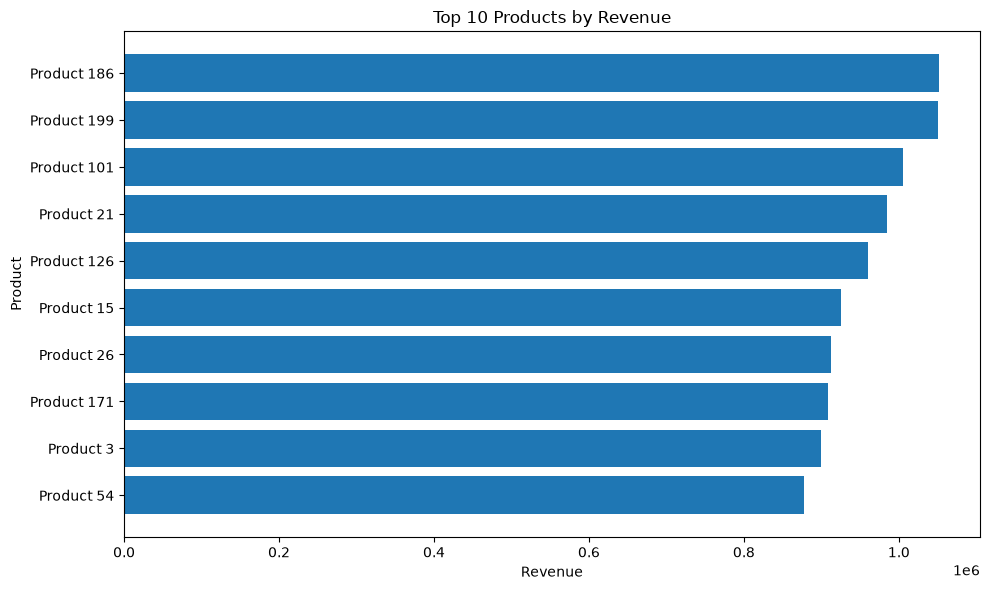

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index[::-1],
    top_products["revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [55]:
# ============================================
# RFM ANALYSIS
# ============================================

customer_rfm = (
    sales_df
    .groupby("customer_id")
    .agg(
        last_purchase=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("sales", "sum")
    )
    .reset_index()
)

customer_rfm.head()

,customer_id,last_purchase,frequency,monetary
0,1,2026-03-19,7,145266.61
1,2,2026-07-23,6,150147.15
2,3,2026-07-18,5,92224.97
3,4,2026-05-13,9,103049.35
4,5,2026-04-30,5,115315.17


In [60]:
analysis_date = sales_df["order_date"].max()

print("Analysis Date:", analysis_date)
customer_rfm["recency"] = (
    analysis_date - customer_rfm["last_purchase"]
).dt.days
customer_rfm.head()

Analysis Date: 2026-08-05 00:00:00


,customer_id,last_purchase,frequency,monetary,recency
0,1,2026-03-19,7,145266.61,139
1,2,2026-07-23,6,150147.15,13
2,3,2026-07-18,5,92224.97,18
3,4,2026-05-13,9,103049.35,84
4,5,2026-04-30,5,115315.17,97


In [64]:
customer_rfm["R_score"] = pd.qcut(
    customer_rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

customer_rfm["F_score"] = pd.qcut(
    customer_rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customer_rfm["M_score"] = pd.qcut(
    customer_rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)
customer_rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score
0,1,2026-03-19,7,145266.61,139,2,4,5
1,2,2026-07-23,6,150147.15,13,5,4,5
2,3,2026-07-18,5,92224.97,18,5,3,3
3,4,2026-05-13,9,103049.35,84,3,5,4
4,5,2026-04-30,5,115315.17,97,3,3,4


In [65]:
customer_rfm["RFM_score"] = (
    customer_rfm["R_score"]
    + customer_rfm["F_score"]
    + customer_rfm["M_score"]
)

customer_rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
0,1,2026-03-19,7,145266.61,139,2,4,5,11
1,2,2026-07-23,6,150147.15,13,5,4,5,14
2,3,2026-07-18,5,92224.97,18,5,3,3,11
3,4,2026-05-13,9,103049.35,84,3,5,4,12
4,5,2026-04-30,5,115315.17,97,3,3,4,10


In [67]:
def segment_customer(row):

    if row["RFM_score"] >= 13:
        return "Champions"

    elif row["RFM_score"] >= 10:
        return "Loyal Customers"

    elif row["RFM_score"] >= 8:
        return "Potential Loyalists"

    elif row["RFM_score"] >= 6:
        return "At Risk"

    else:
        return "Lost Customers"


customer_rfm["segment"] = customer_rfm.apply(
    segment_customer,
    axis=1
)

customer_rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,segment
0,1,2026-03-19,7,145266.61,139,2,4,5,11,Loyal Customers
1,2,2026-07-23,6,150147.15,13,5,4,5,14,Champions
2,3,2026-07-18,5,92224.97,18,5,3,3,11,Loyal Customers
3,4,2026-05-13,9,103049.35,84,3,5,4,12,Loyal Customers
4,5,2026-04-30,5,115315.17,97,3,3,4,10,Loyal Customers


In [68]:
segment_summary = (
    customer_rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        revenue=("monetary", "sum"),
        avg_spend=("monetary", "mean"),
        avg_orders=("frequency", "mean"),
        avg_recency=("recency", "mean")
    )
    .sort_values("revenue", ascending=False)
)

segment_summary

,customers,revenue,avg_spend,avg_orders,avg_recency
segment,,,,,
Loyal Customers,280,32115679.23,114698.854393,6.014286,95.142857
Champions,187,29190683.48,156099.911658,7.855615,39.240642
Potential Loyalists,171,13742636.17,80366.293392,4.538012,118.216374
At Risk,155,9898572.23,63861.756323,3.658065,171.129032
Lost Customers,200,7792724.85,38963.624250,2.520000,300.740000


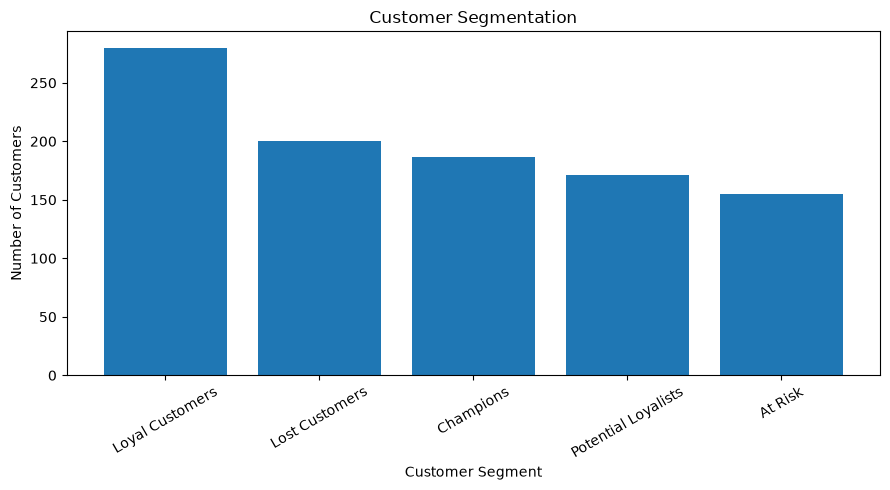

In [69]:
segment_counts = customer_rfm["segment"].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [74]:
customer_rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

segment_summary.to_csv(
    "../data/processed/customer_segment_summary.csv"
)

print("RFM analysis saved successfully.")

RFM analysis saved successfully.


In [75]:
# ============================================
# ABC PRODUCT ANALYSIS
# ============================================

product_abc = (
    sales_df
    .groupby("product_id")
    .agg(
        product_name=("product_name", "first"),
        revenue=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

product_abc.head(10)

,product_id,product_name,revenue,profit,quantity
0,186,Product 186,1052152.61,393669.61,133
1,199,Product 199,1050905.82,322655.82,150
2,101,Product 101,1004803.75,351931.75,132
3,21,Product 21,984793.48,198952.48,161
4,126,Product 126,960064.13,287004.13,146
5,15,Product 15,924878.92,228238.92,160
6,26,Product 26,911868.67,332278.67,121
7,171,Product 171,908353.55,322978.55,125
8,3,Product 3,900049.18,315751.18,117
9,54,Product 54,877122.32,326754.32,144


In [78]:
product_abc["revenue_percentage"] = (
    product_abc["revenue"]
    / product_abc["revenue"].sum()
) * 100

product_abc["cumulative_percentage"] = (
    product_abc["revenue_percentage"].cumsum()
)
product_abc.head(20)

,product_id,product_name,revenue,profit,quantity,revenue_percentage,cumulative_percentage
0,186,Product 186,1052152.61,393669.61,133,1.134515,1.134515
1,199,Product 199,1050905.82,322655.82,150,1.133171,2.267686
2,101,Product 101,1004803.75,351931.75,132,1.083460,3.351145
3,21,Product 21,984793.48,198952.48,161,1.061883,4.413028
4,126,Product 126,960064.13,287004.13,146,1.035218,5.448246
5,15,Product 15,924878.92,228238.92,160,0.997278,6.445525
6,26,Product 26,911868.67,332278.67,121,0.983250,7.428774
7,171,Product 171,908353.55,322978.55,125,0.979459,8.408234
8,3,Product 3,900049.18,315751.18,117,0.970505,9.378739
9,54,Product 54,877122.32,326754.32,144,0.945783,10.324522


In [79]:
def abc_class(row):

    if row["cumulative_percentage"] <= 70:
        return "A"

    elif row["cumulative_percentage"] <= 90:
        return "B"

    else:
        return "C"


product_abc["ABC_class"] = product_abc.apply(
    abc_class,
    axis=1
)

In [80]:
abc_summary = (
    product_abc
    .groupby("ABC_class")
    .agg(
        products=("product_id", "count"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

abc_summary["revenue_percentage"] = (
    abc_summary["revenue"]
    / product_abc["revenue"].sum()
) * 100

abc_summary

,ABC_class,products,revenue,profit,revenue_percentage
0,A,93,64807733.56,16955770.56,69.880879
1,B,47,18400036.12,4606920.12,19.840390
2,C,60,9532526.28,2226522.28,10.278732


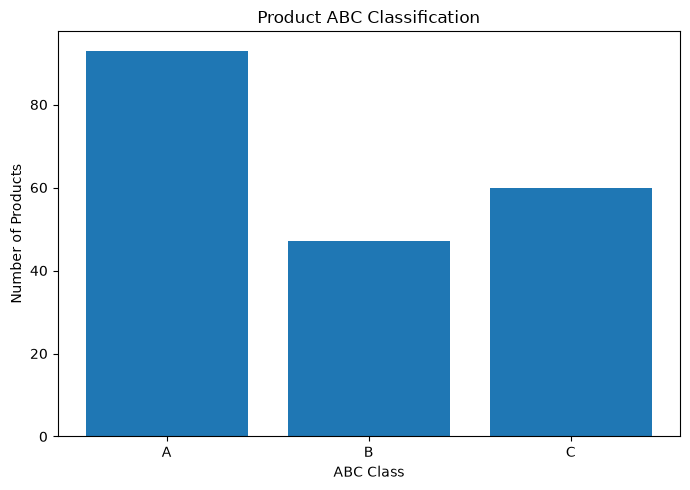

In [81]:
abc_counts = product_abc["ABC_class"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    abc_counts.index,
    abc_counts.values
)

plt.title("Product ABC Classification")
plt.xlabel("ABC Class")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [82]:
product_abc.to_csv(
    "../data/processed/product_abc_analysis.csv",
    index=False
)

abc_summary.to_csv(
    "../data/processed/abc_summary.csv",
    index=False
)

print("ABC analysis saved successfully.")

ABC analysis saved successfully.
